In [1]:
import numpy as np
import pandas as pd

### Work with baseline statistics
    - Completeness, Uniqueness and NLP metrics
    - Number of words, misspelled, lengths and readability
    - Write code for ollama 

In [3]:
from utils import get_baseline_statistics, get_helper_csv_nlp, nlp_quality_metrics, determine_dtype_ft


[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [23]:
from utils import data_completeness, data_uniqueness, outliers_for_num_data, check_spelling, get_words, get_statistics

In [3]:
baseline_sent = pd.read_csv("Sentiment Analysis/baseline.csv")

In [5]:
baseline_sent.head()


,text,target
0,One of the other reviewers has mentioned that ...,positive
1,I thought this was a wonderful way to spend ti...,positive
2,Basically there's a family where a little boy ...,negative
3,I saw this movie when I was about 12 when it c...,negative
4,So im not a big fan of Boll's work but then ag...,negative


In [8]:
sample = get_helper_csv_nlp(baseline_sent)

In [9]:
sample.head()

,text,length,readability
0,One of the other reviewers has mentioned that ...,307,8.0
1,I thought this was a wonderful way to spend ti...,166,11.7
2,Basically there's a family where a little boy ...,138,6.2
3,I saw this movie when I was about 12 when it c...,180,8.7
4,So im not a big fan of Boll's work but then ag...,398,7.7


In [10]:
sample['target'] = baseline_sent['target']

In [11]:
baseline_txt_sum = pd.read_csv("Text Summarization/baseline.csv")
baseline_txt_sum.head()

,text,target
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."


In [12]:
sample_again = get_helper_csv_nlp(baseline_txt_sum)
sample_again.head()

,text,length,readability
0,Ever noticed how plane seats appear to be gett...,370,10.5
1,A drunk teenage boy had to be rescued by secur...,311,10.8
2,Dougie Freedman is on the verge of agreeing a ...,110,8.0
3,Liverpool target Neto is also wanted by PSG an...,308,11.3
4,Bruce Jenner will break his silence in a two-h...,749,10.4


In [13]:
sample_target = get_helper_csv_nlp(baseline_txt_sum, 'target')

In [14]:
sample_target.head()

,target,length,readability
0,Experts question if packed out planes are put...,36,7.6
1,Drunk teenage boy climbed into lion enclosure ...,38,8.0
2,Nottingham Forest are close to extending Dougi...,35,8.6
3,Fiorentina goalkeeper Neto has been linked wit...,44,7.2
4,"Tell-all interview with the reality TV star, 6...",61,12.0


In [15]:
sample_again['target'] = baseline_txt_sum['target']

In [16]:
def get_baseline_statistics(model_name, baseline_data, model_type, output_type=None, target_file=None):
    
    completeness, _, WO_nan, w_nan, missing_data = data_completeness(baseline_data.drop(["target"],axis=1))
    uniqueness_score,u_s, _, _, no_of_rows_wo_dup = data_uniqueness(baseline_data.drop(["target"],axis=1))
    outliers_index = outliers_for_num_data(baseline_data.drop('target', axis=1))
    
    if model_type == "Classification" :
        output_features = get_statistics(baseline_data["target"],"categorical",baseline=True)
    
    if model_type == "Regression":
        output_features = get_statistics(baseline_data["target"],"numerical",baseline=True)
        
    if model_type == "Natural Language Processing (NLP)":
        words = get_words(baseline_data)
        misspelled_words, percentage, _ = check_spelling(words)
        
        if output_type == "Text":

            words_target = get_words(baseline_data, 'target')
            misspell, per_tar, _ = check_spelling(words_target)


            inter_target_dict = {'length': get_statistics(target_file['length'], "numerical", baseline=True),
                                 'readability': get_statistics(target_file['readability'], "numerical", baseline=True)}
            output_features = inter_target_dict

            output_features.update({'Number of words in target column': len(words_target), 
                                   "Number of misspelled words in target column":misspell,
                   "Percentage words misspelled": per_tar})

        if output_type == "Classification":
            output_features = get_statistics(baseline_data["target"],"categorical",baseline=True)
        
        pass
        
    if model_type == "Computer Vision (CV)":
        output_features = get_statistics(baseline_data["target"],"categorical",baseline=True)


    summary = {
        "Number of rows" : float(len(baseline_data)),
        "Number of rows without NaN" : float(WO_nan),
        "Number of rows with NaN" : float(w_nan),
        "Completeness score" : float(completeness),
        "Uniqueness score" : float(uniqueness_score),
        "Number of rows without duplicates" : float(no_of_rows_wo_dup),
        "Number of rows with from duplicates" : float(len(baseline_data) - no_of_rows_wo_dup)
    }
    
    summary.update({'Number of words in text column': len(words), "Number of misspelled words in text column":misspelled_words, 
                   "Percentage words misspelled": percentage}) if model_type == 'Natural Language Processing (NLP)' else summary
   
    cols = baseline_data.drop(["target"],axis=1).columns if 'text' not in baseline_data.columns else baseline_data.drop(["target", "text"],axis=1).columns
    input_features = dict()
    input_u_s = {u_s['Feature'][i] : round(u_s['Value'][i],2) for i in range(len(u_s['Feature']))}
    outliers = {i : float(len(outliers_index[i])) for i in outliers_index}
    categorical_ft, numerical_ft = determine_dtype_ft(baseline_data.drop(["target"],axis = 1))


    for i in cols:
        input_features[i] = {
                "Number of missing values" : float(dict(missing_data)[i]),
                "Uniqueness score" : float(input_u_s[i]),
                "Number of outliers" : float(outliers[i]),
                }

        if i in categorical_ft:
            input_features[i].update(get_statistics(baseline_data[i], "categorical",baseline=True))
        if i in numerical_ft:
            input_features[i].update(get_statistics(baseline_data[i], "numerical",baseline=True))
    
    results_dict = {model_name : {"Baseline Data Summary": summary, "Input Feature Details": input_features, "Target": output_features}}
    
    return results_dict


In [17]:
results_dict = get_baseline_stats("Sentiment", sample
                                  , "Natural Language Processing (NLP)", output_type="Classification")

NameError: name 'get_baseline_stats' is not defined

In [50]:
results_dict

{'Sentiment': {'Baseline Data Summary': {'Number of rows': 1000.0,
   'Number of rows without NaN': 1000.0,
   'Number of rows with NaN': 0.0,
   'Completeness score': 100.0,
   'Uniqueness score': 100.0,
   'Number of rows without duplicates': 1000.0,
   'Number of rows with duplicates': 0.0,
   'Number of words in text column': 229246,
   'Number of misspelled words in text column': 5681,
   'Percentage words misspelled': 27.0},
  'Input Feature Details': {'length': {'Number of missing values': 0.0,
    'Uniqueness score': 41.6,
    'Number of outliers': 81.0,
    'mean': 227.34,
    'median': 172.0,
    'std': 160.45,
    'min': 26.0,
    'max': 1296.0,
    'iqr': 146.0},
   'readability': {'Number of missing values': 0.0,
    'Uniqueness score': 15.1,
    'Number of outliers': 36.0,
    'mean': 8.96,
    'median': 8.5,
    'std': 3.04,
    'min': 2.9,
    'max': 27.4,
    'iqr': 3.5}},
  'Target': {'mode': 'positive',
   'value_counts': {'positive': 513, 'negative': 487}}}}

In [54]:
new_results_dict = get_baseline_stats("Text Summ", sample_again, "Natural Language Processing (NLP)", output_type='Text', target_file=sample_target)

In [55]:
new_results_dict

{'Text Summ': {'Baseline Data Summary': {'Number of rows': 100.0,
   'Number of rows without NaN': 100.0,
   'Number of rows with NaN': 0.0,
   'Completeness score': 100.0,
   'Uniqueness score': 100.0,
   'Number of rows without duplicates': 100.0,
   'Number of rows with duplicates': 0.0,
   'Number of words in text column': 62608,
   'Number of misspelled words in text column': 1509,
   'Percentage words misspelled': 16.0},
  'Input Feature Details': {'length': {'Number of missing values': 0.0,
    'Uniqueness score': 95.0,
    'Number of outliers': 4.0,
    'mean': 631.99,
    'median': 564.5,
    'std': 330.24,
    'min': 110.0,
    'max': 1524.0,
    'iqr': 429.25},
   'readability': {'Number of missing values': 0.0,
    'Uniqueness score': 57.0,
    'Number of outliers': 0.0,
    'mean': 10.64,
    'median': 10.5,
    'std': 1.77,
    'min': 6.5,
    'max': 14.5,
    'iqr': 2.674999999999999}},
  'Target': {'length': {'mean': 51.88,
    'median': 50.0,
    'std': 18.53,
    'min

In [7]:
from utils import get_results, get_fishbone

In [8]:
import json

In [9]:
with open("../pages/model_info.json", "r") as e:
    model_info = json.load(e)

In [10]:
benchmark_sent = model_info['Sentiment Analysis Testing 2']['benchmark_metrics']

In [11]:
baseline_sent.head()

,text,target
0,One of the other reviewers has mentioned that ...,positive
1,I thought this was a wonderful way to spend ti...,positive
2,Basically there's a family where a little boy ...,negative
3,I saw this movie when I was about 12 when it c...,negative
4,So im not a big fan of Boll's work but then ag...,negative


In [12]:
production = pd.read_csv("Sentiment Analysis/Production Runs/01st Dec 2023.csv")

In [14]:
production.head()

,text,target
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


In [24]:
gt = pd.read_csv("Sentiment Analysis/Ground Truths/01st Dec 2023.csv")

In [26]:
gt.head()

,text,target
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


In [28]:
tex_summ_results = get_results('Sentiment Analysis', "01st Dec 2023",
                               gt, production, baseline_sent, "Natural Language Processing (NLP)", benchmark_sent)

Results dictionary created


In [29]:
tex_summ_results

{'Sentiment Analysis': {'01st Dec 2023': {'Production Data Summary': {'Number of rows': 1000,
    'Number of rows without NaN': 1000.0,
    'Number of rows with Nan': 0.0,
    'Completeness Score': 100.0,
    'Uniqueness Score': 100.0,
    'Number of rows without duplicates': 1000.0,
    'Number of rows with duplicates': 0.0,
    'Metrics': {'Accuracy': 86.6,
     'Precision': 88.17,
     'Recall': 82.98,
     'F1': 85.5,
     'ROC_AUC': 0,
     'False Positive Rate': 10.11},
    'Drifting Metrics': []},
   'Input Feature Details': {'text': {'Number of missing values': 0.0,
     'Uniqueness Score': 100.0,
     'Number of datatype mismatches': 1000.0,
     'Number of outliers': 0.0,
     'Readability': {'Maximum': 39.5, 'Minimum': 1.0, 'Average': 7.96},
     'Length': {'Maximum': 1010, 'Minimum': 37, 'Average': 233.77},
     'Spelling error': 28.0,
     'Vocabulary': 21042,
     'Misspelled words': 5865,
     'Correct words': 15177,
     'Syntax Drift': {'Type-Token Ratio (%)': 9.0,
   

In [41]:
baseline_txt_sum.head()

,text,target
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."


In [53]:
production_summ = pd.read_csv("Text Summarization/Production Runs/2024-02-28.csv")[['text', 'target']]

In [54]:
production_summ.head()

,text,target
0,Comedian Jenny Eclair travelled with her other...,Comedian Jenny Eclair travelled with her other...
1,A woman of Arab and Jewish descent who was str...,"Shoshana Hebshi, of Sylvania, Ohio, was forced..."
2,World No 1 Novak Djokovic has apologised to th...,Novak Djokovic lost his cool during the Miami ...
3,(CNN)ISIS on Wednesday released more than 200 ...,"ISIS released more than 200 Yazidis, a minorit..."
4,Hillary Clinton’s security detail arrived at a...,Two Scooby vans arrived at Capitol Fruit Compa...


In [55]:
gt_summ = pd.read_csv("Text Summarization/Ground Truths/2024-02-28.csv")[['text', 'target']]

In [56]:
gt_summ.head()

,text,target
0,Comedian Jenny Eclair travelled with her other...,The comedian stayed with Flavours who offer a ...
1,A woman of Arab and Jewish descent who was str...,The federal government will give Shoshana Hebs...
2,World No 1 Novak Djokovic has apologised to th...,Novak Djokovic beat Andy Murray 7-6 4-6 6-0 in...
3,(CNN)ISIS on Wednesday released more than 200 ...,Most of those released were women and children...
4,Hillary Clinton’s security detail arrived at a...,"Second modified, armored van spotted near Des ..."


In [47]:
benchmark_summ = {"Similarity": 0.63, "F1": 27, "Recall": 30, "Precision": 35, "BLEU": 0.58}

In [57]:
tex_summ_results = get_results('Text Summarization', "2024-02-28",
                               gt_summ, production_summ, baseline_txt_sum, "Text", benchmark_summ)

D:\Anaconda\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning:


The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()

D:\Anaconda\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning:


The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()

D:\Anaconda\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning:


The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()



Results dictionary created


In [59]:
tex_summ_results

{'Text Summarization': {'2024-02-28': {'Production Data Summary': {'Number of rows': 50,
    'Number of rows without NaN': 50.0,
    'Number of rows with Nan': 0.0,
    'Completeness Score': 100.0,
    'Uniqueness Score': 100.0,
    'Number of rows without duplicates': 50.0,
    'Number of rows with duplicates': 0.0,
    'Metrics': {'Precision': 37.14,
     'F1': 36.26,
     'Recall': 38.25,
     'BLEU': 0.0,
     'Similarity': 0.98},
    'Drifting Metrics': ['BLEU']},
   'Input Feature Details': {'text': {'Number of missing values': 0.0,
     'Uniqueness Score': 100.0,
     'Number of datatype mismatches': 50.0,
     'Number of outliers': 0.0,
     'Readability': {'Maximum': 14.6, 'Minimum': 4.7, 'Average': 9.48},
     'Length': {'Maximum': 1521, 'Minimum': 135, 'Average': 645.36},
     'Spelling error': 12.0,
     'Vocabulary': 6175,
     'Misspelled words': 758,
     'Correct words': 5417,
     'Syntax Drift': {'Type-Token Ratio (%)': 19.0,
      'Vocabulary drift score (%)': 29.48,

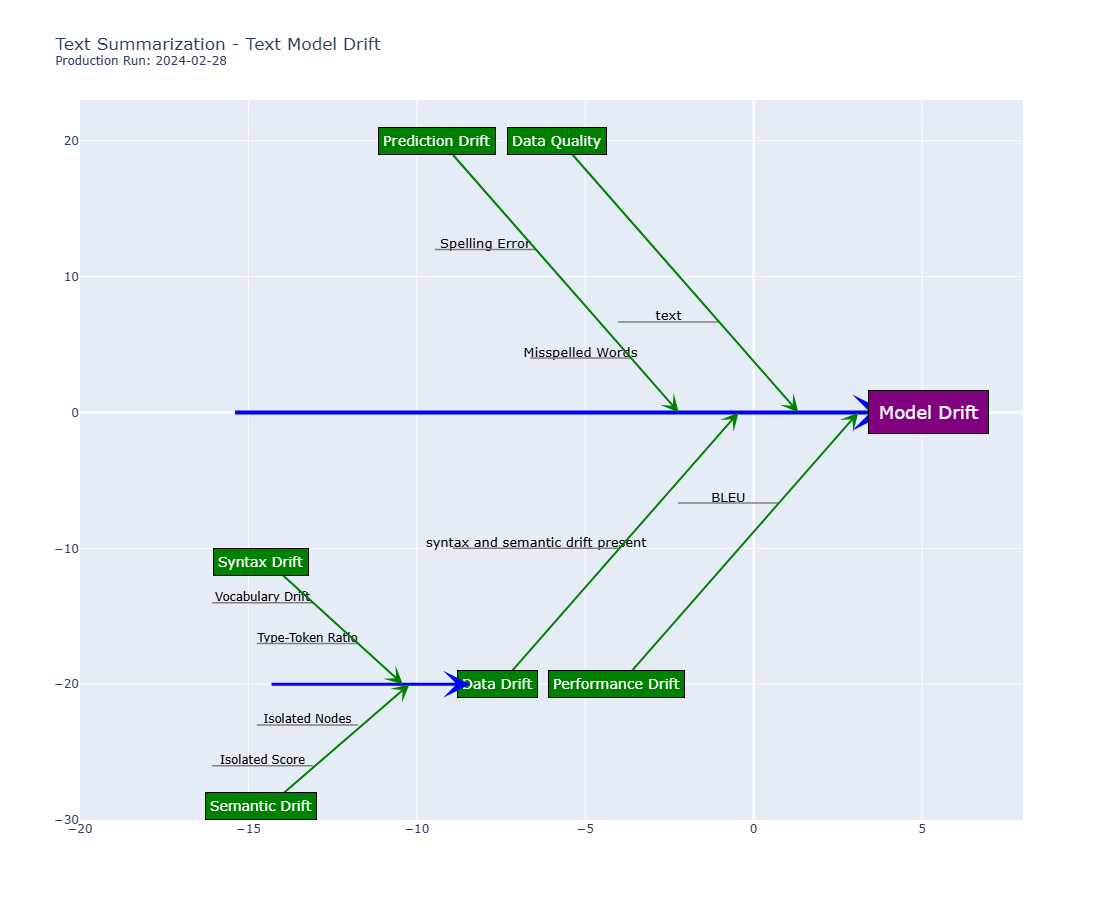

In [61]:
get_fishbone(model_type="Text",
                      results=tex_summ_results,
                      model_name="Text Summarization",
                      production_run_date="2024-02-28",
                      benchmark_metrics=benchmark_summ)

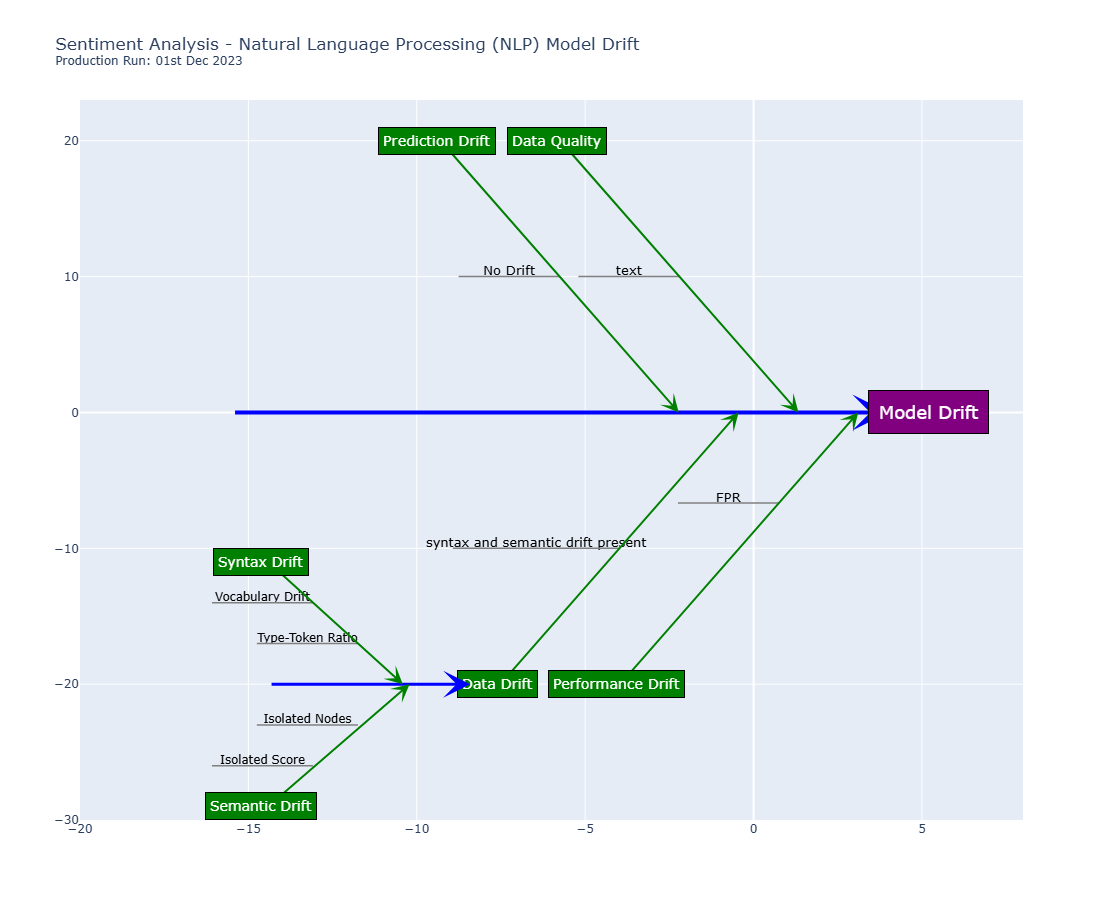

In [63]:
'Sentiment Analysis', "01st Dec 2023"
get_fishbone(model_type="Natural Language Processing (NLP)",
                      results=tex_summ_results,
                      model_name="Sentiment Analysis",
                      production_run_date="01st Dec 2023",
                      benchmark_metrics=benchmark_sent)

In [32]:
def new_filter_data(df, num_conds, cat_conds, text_conds):
    
    """
    df: DataFrame to filter
    num_conds: Numerical Conditions that we get from webpage
    cat_conds: Categorical Conditions that we get from webpage
    
    Returns the filtered DataFrame
    """
    
    for i in list(cat_conds.keys()):
        unique_cats = list(df[i].unique())
        if not all([j in unique_cats for j in cat_conds[i]]):
            print("Wrong Category Entered, Can't Filter")
            return None
        else:
            df = df[df[i].isin(cat_conds[i])]
    
    for i in list(num_conds.keys()):
        if '-' in num_conds[i]:
            splits = num_conds[i].split('-')
            limits = [df[i].min() if splits[0] == '' else float(splits[0]), df[i].max() if splits[1] == '' else float(splits[1])]
            
            df = df[(df[i]>=limits[0]) & (df[i]<=limits[1])]
        else:
            try:
                df = df[df[i] == float(num_conds[i])]
            except:
                print("Invalid format to filter Numerical Columns")
                return None

    for i in list(text_conds.keys()):
        try:
            df = df[df['text'].str.contains(text_conds[i],case=False,na=False)]
        except:
            print("Invalid format to filter Text Columns")
            return None
    
    return df

In [34]:
with open("../pages/results.json", "r") as e:
    results = json.load(e)

In [38]:
list(results.keys())

['Heart Disease Prediction',
 'Heart Disease Classification',
 'Medical Cost Prediction',
 'Bone Fracture',
 'Sentiment Analysis Testing 2',
 'Text Summarization']

In [44]:
tex_summ_results

{'Sentiment Analysis': {'01st Dec 2023': {'Production Data Summary': {'Number of rows': 1000,
    'Number of rows without NaN': 1000.0,
    'Number of rows with Nan': 0.0,
    'Completeness Score': 100.0,
    'Uniqueness Score': 100.0,
    'Number of rows without duplicates': 1000.0,
    'Number of rows with duplicates': 0.0,
    'Metrics': {'Accuracy': 86.6,
     'Precision': 88.17,
     'Recall': 82.98,
     'F1': 85.5,
     'ROC_AUC': 0,
     'False Positive Rate': 10.11},
    'Drifting Metrics': []},
   'Input Feature Details': {'text': {'Number of missing values': 0.0,
     'Uniqueness Score': 100.0,
     'Number of datatype mismatches': 1000.0,
     'Number of outliers': 0.0,
     'Readability': {'Maximum': 39.5, 'Minimum': 1.0, 'Average': 7.96},
     'Length': {'Maximum': 1010, 'Minimum': 37, 'Average': 233.77},
     'Spelling error': 28.0,
     'Vocabulary': 21042,
     'Misspelled words': 5865,
     'Correct words': 15177,
     'Syntax Drift': {'Type-Token Ratio (%)': 9.0,
   

In [46]:
results['Text Summarization'].update(tex_summ_results['Sentiment Analysis'])

In [48]:
results['Text Summarization']

{'2026-01-05': {'Production Data Summary': {'Number of rows': 50,
   'Number of rows without NaN': 50.0,
   'Number of rows with Nan': 0.0,
   'Completeness Score': 100.0,
   'Uniqueness Score': 100.0,
   'Number of rows without duplicates': 50.0,
   'Number of rows with duplicates': 0.0,
   'Metrics': {'Precision': 38.89,
    'F1': 40.56,
    'Recall': 43.93,
    'BLEU': 0.0,
    'Similarity': 0.99},
   'Drifting Metrics': []},
  'Input Feature Details': {'text': {'Number of missing values': 0.0,
    'Uniqueness Score': 100.0,
    'Number of datatype mismatches': 50.0,
    'Number of outliers': 0.0,
    'Readability': {'Maximum': 15.0, 'Minimum': 7.3, 'Average': 10.59},
    'Length': {'Maximum': 1169, 'Minimum': 164, 'Average': 559.56},
    'Spelling error': 15.0,
    'Vocabulary': 5415,
    'Misspelled words': 794,
    'Correct words': 4621,
    'Syntax Drift': {'Type-Token Ratio (%)': 20.0,
     'Vocabulary drift score (%)': 23.56,
     'Frequency Based Syntax Drift': {'ks-stat': 0.

In [7]:
from utils import new_filter_data


[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [8]:
baseline_sent

,text,target
0,One of the other reviewers has mentioned that ...,positive
1,I thought this was a wonderful way to spend ti...,positive
2,Basically there's a family where a little boy ...,negative
3,I saw this movie when I was about 12 when it c...,negative
4,So im not a big fan of Boll's work but then ag...,negative
...,...,...
995,Alright! A sci-fi/horror/action B-hybrid direc...,negative
996,"I thought I had seen this movie, twice in fact...",negative
997,"I saw this on DVD with subtitles, which made i...",positive
998,"This show, Paranormal State, has an almost ""Bl...",negative


In [9]:
text_conds, cat_conds = dict(), dict()

In [10]:
cat_conds['target'] = [baseline_sent['target'].unique().tolist()[0]]

In [11]:
text_conds['text'] = 'Die,Hard'.split(',')

In [12]:
cat_conds

{'target': ['positive']}

In [13]:
text_conds

{'text': ['Die', 'Hard']}

In [14]:
filtered = new_filter_data(df=baseline_sent, 
                           text_conds=text_conds,
                           cat_conds=cat_conds)

In [15]:
filtered.head()

,text,target
9,After the success of Die Hard and it's sequels...,positive


In [43]:
baseline_sent.head()

,text,target
0,One of the other reviewers has mentioned that ...,positive
1,I thought this was a wonderful way to spend ti...,positive
2,Basically there's a family where a little boy ...,negative
3,I saw this movie when I was about 12 when it c...,negative
4,So im not a big fan of Boll's work but then ag...,negative


In [45]:
all(word in filtered.iloc[0]['text'] for word in text_conds['text'])

False

In [47]:
[word in filtered.iloc[0]['text'] for word in text_conds['text']]

[False, False]

In [37]:
unique_cats = list(baseline_sent[i].unique())

In [39]:
unique_cats

['positive', 'negative']

In [35]:
for i in list(cat_conds.keys()):
    unique_cats = list(baseline_sent[i].unique())
    print(all([j in unique_cats for j in cat_conds[i]]))

False


In [49]:
def check_words(text):
    if all(i in words for i in text.split()):
        return text

In [51]:
words = ['mentioned']

In [ ]:
filtered_txt = filtered_['text']

In [27]:
[1,2,3] + [3]

[1, 2, 3, 3]